
<div class="alert alert-block alert-success">
<font size="3"><b>Problem Statement:</b> A bike-sharing system is a service in which bikes are made available for shared use to individuals on a short term basis for a price or free. Many bike share systems allow people to borrow a bike from a "dock" which is usually computer-controlled wherein the user enters the payment information, and the system unlocks it. This bike can then be returned to another dock belonging to the same system.


A US bike-sharing provider BoomBikes has recently suffered considerable dips in their revenues due to the ongoing Corona pandemic. The company is finding it very difficult to sustain in the current market scenario. So, it has decided to come up with a mindful business plan to be able to accelerate its revenue as soon as the ongoing lockdown comes to an end, and the economy restores to a healthy state. 


In such an attempt, BoomBikes aspires to understand the demand for shared bikes among the people after this ongoing quarantine situation ends across the nation due to Covid-19. They have planned this to prepare themselves to cater to the people's needs once the situation gets better all around and stand out from other service providers and make huge profits.


They have contracted a consulting company to understand the factors on which the demand for these shared bikes depends. Specifically, they want to understand the factors affecting the demand for these shared bikes in the American market. The company wants to know:

1>Which variables are significant in predicting the demand for shared bikes.
2>How well those variables describe the bike demands</font>
</div>

 <div class="alert alert-block alert-info">
<font size="5"><b>1:</b> Data understanding, preparation and EDA.</font>
</div>

 <div class="alert alert-block alert-info">
<font size="2">Importing all necesary module.</font>
</div> 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

 <div class="alert alert-block alert-info">
<font size="2">Reading the data which  service provider firm has gathered a large dataset on daily bike demands across the American market based on some factors. </font>
</div> 

In [2]:
bike_demand_data = pd.read_csv('day.csv')
# since instant is just a serial number, we dont require in analysis, hence dropping this column.
bike_demand_data= bike_demand_data.drop('instant',axis = 1)
bike_demand_data.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [3]:
bike_demand_data.shape

(730, 15)

 <div class="alert alert-block alert-info">
<font size="2"><b>1.1:</b> Performing EDA</font>
</div>

 <div class="alert alert-block alert-info">
<font size="3"> Analysing  target variable first to be ensured that data provided to us is correct as our analysis will greatly be dependent of TARGET variable
    </font>
</div> 

In [4]:
bike_demand_data.cnt.describe()

count     730.000000
mean     4508.006849
std      1936.011647
min        22.000000
25%      3169.750000
50%      4548.500000
75%      5966.000000
max      8714.000000
Name: cnt, dtype: float64

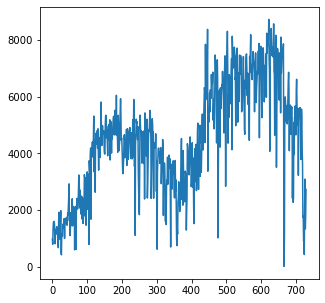

In [5]:
# Univariate analysis for target variable 'cnt'

plt.figure(figsize=(5,5))
plt.plot(bike_demand_data.cnt)
plt.show()

#### 
<div class="alert alert-block alert-success">
<font size="3"><b>Inference:</b> The trend is going downward. 
    </font >
</div>


 <div class="alert alert-block alert-info">
<font size="3"> NULL CHECK.</font>
</div>

#### MISSING ARE ALSO CATEOGARISED as Nan

In [6]:
x=bike_demand_data.columns.tolist()
def perc(i):
    null_values=bike_demand_data[i].isnull().sum()
    total_value=bike_demand_data[i].shape[0]
    null_percentage=null_values/total_value
    return null_percentage
for i in x:
    print(i,perc(i))

dteday 0.0
season 0.0
yr 0.0
mnth 0.0
holiday 0.0
weekday 0.0
workingday 0.0
weathersit 0.0
temp 0.0
atemp 0.0
hum 0.0
windspeed 0.0
casual 0.0
registered 0.0
cnt 0.0


#### 
<div class="alert alert-block alert-success">
<font size="3"><b>Inference:</b> No null values present in dataset :).
    </font >
</div>


 <div class="alert alert-block alert-info">
<font size="3"> Checking duplicates in data</font>
</div>

In [7]:
bike_dup = bike_demand_data.copy()

# Checking for duplicates and dropping the entire duplicate row if any
bike_dup.drop_duplicates(subset=None, inplace=True)

In [8]:
bike_dup.shape



(730, 15)

In [9]:
bike_demand_data.shape

(730, 15)

#### 
<div class="alert alert-block alert-success">
<font size="3"><b>Inference:</b> No duplicates present :).
    </font >
</div>


 <div class="alert alert-block alert-info">
<font size="2"> Junk check</font>
</div>

In [10]:
bike_dup=bike_demand_data.iloc[:,1:16]
for col in bike_dup:
    print(bike_dup[col].value_counts(ascending=False), '\n\n')

3    188
2    184
1    180
4    178
Name: season, dtype: int64 


0    365
1    365
Name: yr, dtype: int64 


1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     56
Name: mnth, dtype: int64 


0    709
1     21
Name: holiday, dtype: int64 


1    105
2    105
3    104
4    104
5    104
6    104
0    104
Name: weekday, dtype: int64 


1    504
0    226
Name: workingday, dtype: int64 


1    463
2    246
3     21
Name: weathersit, dtype: int64 


26.035000    5
10.899153    5
27.880000    4
28.563347    4
23.130847    4
            ..
27.435847    1
26.376653    1
28.989419    1
28.700000    1
8.849153     1
Name: temp, Length: 498, dtype: int64 


32.73440    4
18.78105    3
31.85040    3
28.59875    2
23.32625    2
           ..
28.94730    1
30.46145    1
30.10650    1
31.34500    1
11.17435    1
Name: atemp, Length: 689, dtype: int64 


61.3333    4
63.0833    3
55.2083    3
60.5000    3
56.8333    3
          ..
54.8333    1
56.17

#### 
<div class="alert alert-block alert-success">
<font size="3"><b>Inference:</b> No junk present
    </font >
</div>


 <div class="alert alert-block alert-info">
<font size="5"> Checking data present in each attributes</font>
</div>

In [11]:
x=bike_demand_data.columns.tolist()
for i in x:
    print(str.capitalize(i),bike_demand_data[i].unique())
    print('-------------------------------------------------------------------------------------------')

Dteday ['01-01-2018' '02-01-2018' '03-01-2018' '04-01-2018' '05-01-2018'
 '06-01-2018' '07-01-2018' '08-01-2018' '09-01-2018' '10-01-2018'
 '11-01-2018' '12-01-2018' '13-01-2018' '14-01-2018' '15-01-2018'
 '16-01-2018' '17-01-2018' '18-01-2018' '19-01-2018' '20-01-2018'
 '21-01-2018' '22-01-2018' '23-01-2018' '24-01-2018' '25-01-2018'
 '26-01-2018' '27-01-2018' '28-01-2018' '29-01-2018' '30-01-2018'
 '31-01-2018' '01-02-2018' '02-02-2018' '03-02-2018' '04-02-2018'
 '05-02-2018' '06-02-2018' '07-02-2018' '08-02-2018' '09-02-2018'
 '10-02-2018' '11-02-2018' '12-02-2018' '13-02-2018' '14-02-2018'
 '15-02-2018' '16-02-2018' '17-02-2018' '18-02-2018' '19-02-2018'
 '20-02-2018' '21-02-2018' '22-02-2018' '23-02-2018' '24-02-2018'
 '25-02-2018' '26-02-2018' '27-02-2018' '28-02-2018' '01-03-2018'
 '02-03-2018' '03-03-2018' '04-03-2018' '05-03-2018' '06-03-2018'
 '07-03-2018' '08-03-2018' '09-03-2018' '10-03-2018' '11-03-2018'
 '12-03-2018' '13-03-2018' '14-03-2018' '15-03-2018' '16-03-2018'
 '1

#### 
<div class="alert alert-block alert-success">
<font size="3"><b>Inference:</b> No issue in data quality
    </font >
</div>


In [12]:
bike_demand_data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      730 non-null    object 
 1   season      730 non-null    int64  
 2   yr          730 non-null    int64  
 3   mnth        730 non-null    int64  
 4   holiday     730 non-null    int64  
 5   weekday     730 non-null    int64  
 6   workingday  730 non-null    int64  
 7   weathersit  730 non-null    int64  
 8   temp        730 non-null    float64
 9   atemp       730 non-null    float64
 10  hum         730 non-null    float64
 11  windspeed   730 non-null    float64
 12  casual      730 non-null    int64  
 13  registered  730 non-null    int64  
 14  cnt         730 non-null    int64  
dtypes: float64(4), int64(10), object(1)
memory usage: 85.7+ KB


#### 
<div class="alert alert-block alert-success">
<font size="3"><b>Inference:</b> We have no cateogarical variable. variables like 'weathersit' and 'season' have values as 1, 2, 3, 4
    which needs to have meaningful names attached to it. Refering dictionary we will convert numbers to string names.
    </font >
</div>


 <div class="alert alert-block alert-info">
<font size="2"> Identifying the weekend</font>
</div>

In [13]:
identify_weekday=bike_demand_data.iloc[0:7,6:8]#[['weekday'],['workingday']]
identify_weekday

,workingday,weathersit
0,1,2
1,1,2
2,1,1
3,1,1
4,1,1
5,0,1
6,0,2


#### 
<div class="alert alert-block alert-success">
<font size="3"><b>Inference:</b>  6 and 0 are weekend since weathersit are not 1 for them. we can name it saturday and sunday respectively
    </font >
</div>


 <div class="alert alert-block alert-info">
<font size="3"> Attaching meaningful names to dummy variable in attributes like weathersit and weekday. </font>
</div>

 <div class="alert alert-block alert-info">
<font size="3"> Dta Preparation. </font>
</div>

 <div class="alert alert-block alert-info">
<font size="2"> weathersit </font>
</div>

In [14]:
# List of variables to map

varlist =  ['weathersit']

# Defining the map function
def binary_map(x):
    return x.map({1:'Good_weather', 2:'moderate_weather',3:'bad_weather'})

# Applying the function to the housing list
bike_demand_data[varlist] = bike_demand_data[varlist].apply(binary_map)

 <div class="alert alert-block alert-info">
<font size="2"> season </font>
</div>

In [15]:
# List of variables to map

varlist =  ['season']

# Defining the map function
def binary_map(x):
    return x.map({1:'spring', 2:'summer', 3:'fall', 4:'winter'})

# Applying the function to the housing list
bike_demand_data[varlist] = bike_demand_data[varlist].apply(binary_map)

 <div class="alert alert-block alert-info">
<font size="2"> mnth </font>
</div>

In [16]:
# List of variables to map

varlist =  ['mnth']

# Defining the map function
def binary_map(x):
    return x.map({1:'january', 2:'february', 3:'march', 4:'april', 5:'may', 6:'june', 7:'july', 8:'august', 9:'september',
                                10:'october', 11:'november', 12:'december' })

# Applying the function to the housing list
bike_demand_data[varlist] = bike_demand_data[varlist].apply(binary_map)

 <div class="alert alert-block alert-info">
<font size="2"> weekday </font>
</div>

In [17]:
# List of variables to map

varlist =  ['weekday']

# Defining the map function
def binary_map(x):
    return x.map({0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'})

# Applying the function to the housing list
bike_demand_data[varlist] = bike_demand_data[varlist].apply(binary_map)

In [18]:
bike_demand_data.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,01-01-2018,spring,0,january,0,Mon,1,moderate_weather,14.110847,18.18125,80.5833,10.749882,331,654,985
1,02-01-2018,spring,0,january,0,Tue,1,moderate_weather,14.902598,17.68695,69.6087,16.652113,131,670,801
2,03-01-2018,spring,0,january,0,Wed,1,Good_weather,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,04-01-2018,spring,0,january,0,Thu,1,Good_weather,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,05-01-2018,spring,0,january,0,Fri,1,Good_weather,9.305237,11.46350,43.6957,12.522300,82,1518,1600


 <div class="alert alert-block alert-info">
<font size="3"> Removing unwanted columns from dataframe
    
    instant: Its only an index value

    dteday : This has the date, Since we already have seperate columns for 'year' & 'month',hence, we could live without this column.

    casual & registered : Both these columns contains the count of bike booked by different categories of customers. Since our objective is to find the total count of bikes and not by specific category, we will ignore these two columns. More over, we have created a new variable to have the ratio of these customer types.

 </font>
</div>


In [19]:
rl=['dteday','casual','registered']
for i in bike_demand_data.columns.tolist():
    if( i in rl ):
        bike_demand_data.drop([i], axis = 1, inplace = True)

In [20]:
bike_demand_data.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

 <div class="alert alert-block alert-info">
<font size="3"> Visualising the data. </font>
</div>

 <div class="alert alert-block alert-info">
<font size="3"> Visualising Numeric Variables. </font>
</div>

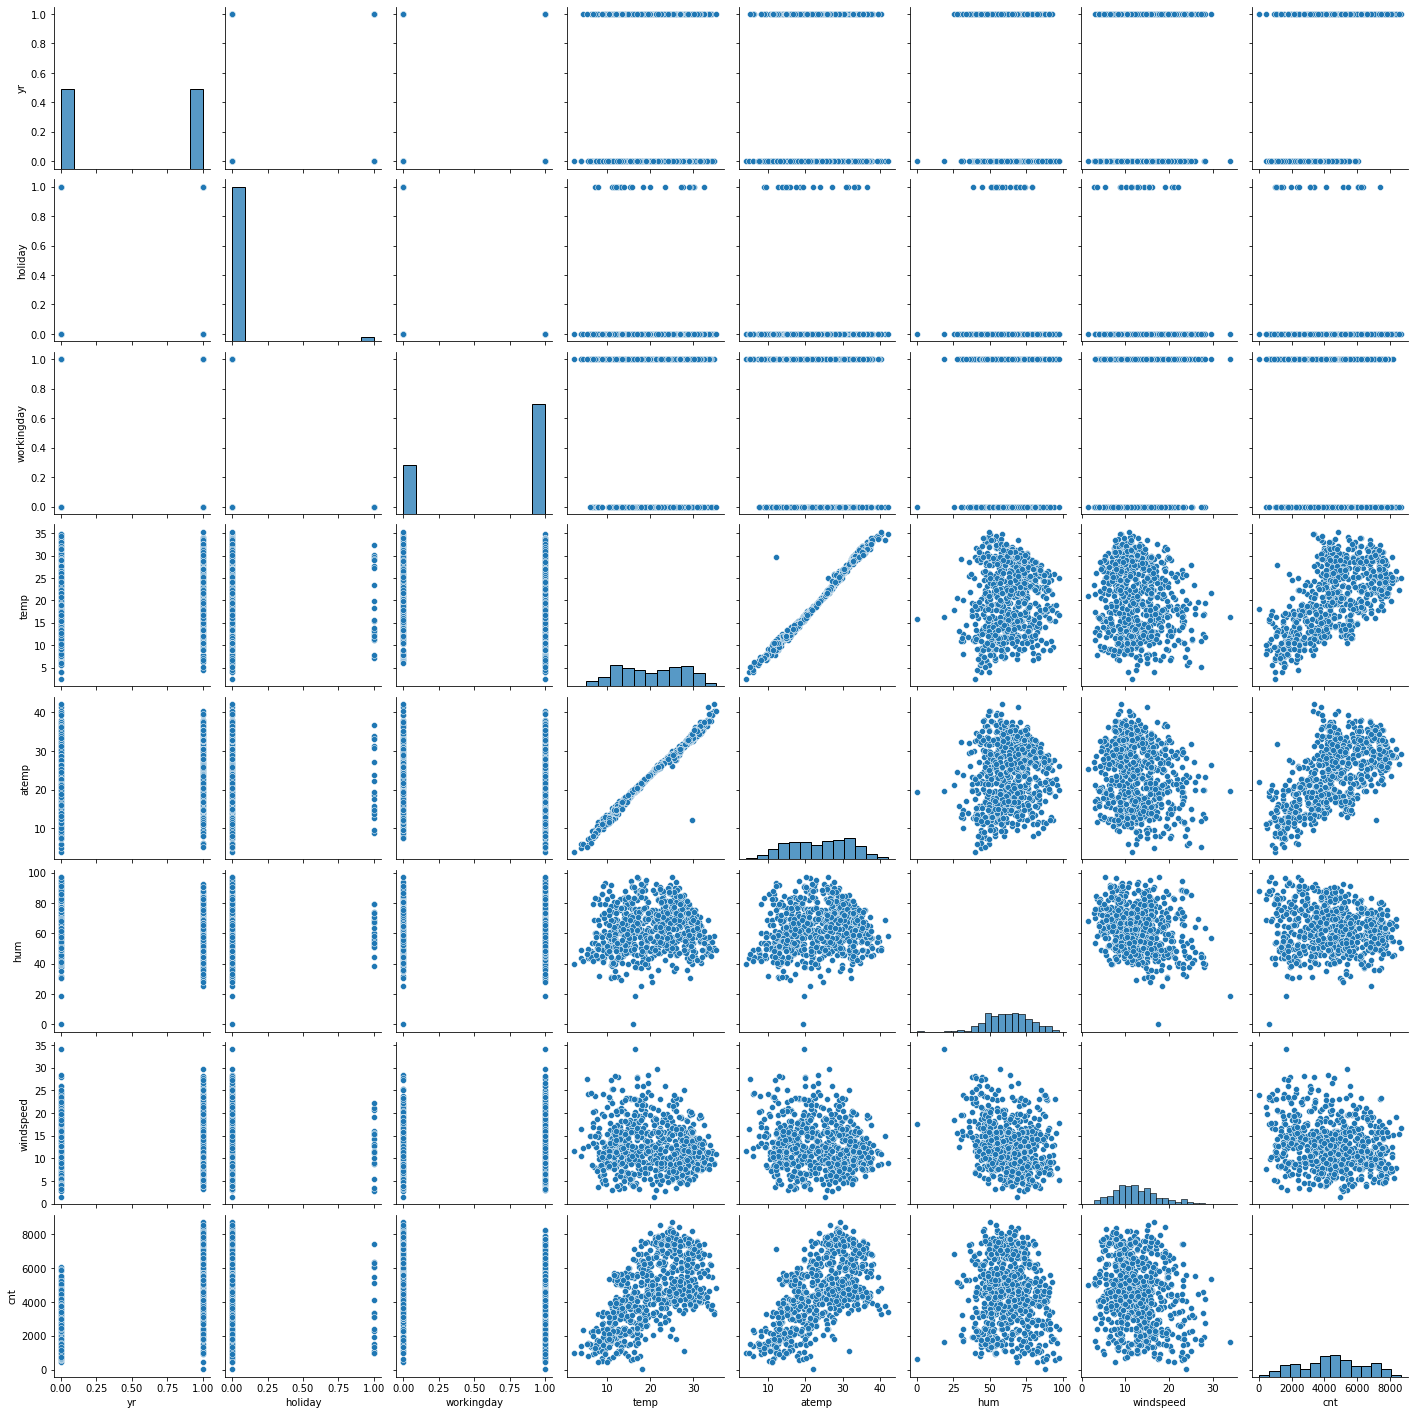

In [21]:
sns.pairplot(bike_demand_data)
plt.show()

 <div class="alert alert-block alert-info">
<font size="3"> Visualising cateogarical Variables. </font>
</div>

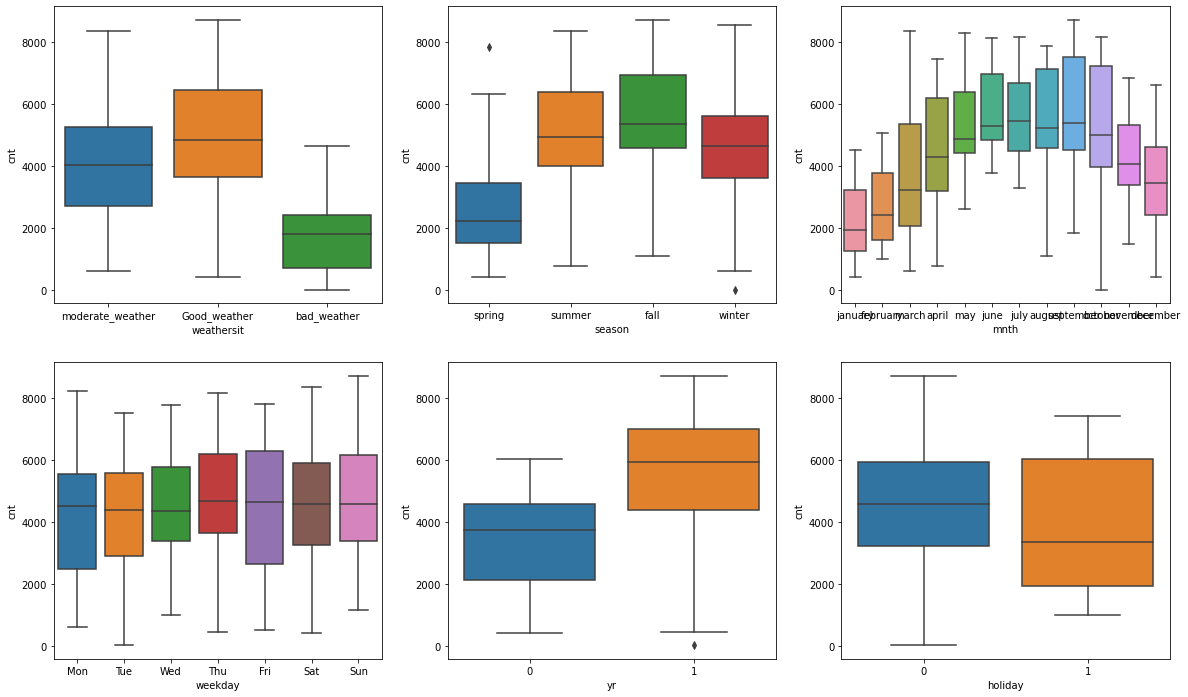

In [22]:
plt.figure(figsize=(20, 12))
plt.subplot(2,3,1)
sns.boxplot(x = 'weathersit', y = 'cnt', data = bike_demand_data)
plt.subplot(2,3,2)
sns.boxplot(x = 'season', y = 'cnt', data = bike_demand_data)
plt.subplot(2,3,3)
sns.boxplot(x = 'mnth', y = 'cnt', data = bike_demand_data)
plt.subplot(2,3,4)
sns.boxplot(x = 'weekday', y = 'cnt', data = bike_demand_data)
plt.subplot(2,3,5)
sns.boxplot(x = 'yr', y = 'cnt', data = bike_demand_data)
plt.subplot(2,3,6)
sns.boxplot(x = 'holiday', y = 'cnt', data = bike_demand_data)

plt.show()

#### 
<div class="alert alert-block alert-success">
    <font size="3"><b>Inference:</b>
        <b>1.</b>People prefer to drive in good weather.
        <b>2.</b>Rental bike is used maximum in fall season. 
        <b>3.</b>During holiday. rental bikes demand has decreased. 
        <b>4.</b>year 2019 or next year has more rental users than 2018.
        <b>5.</b>Demand is continuously growing every month till June. September month has the highest demand. After September, demand is decreasing.
    </font >
</div>


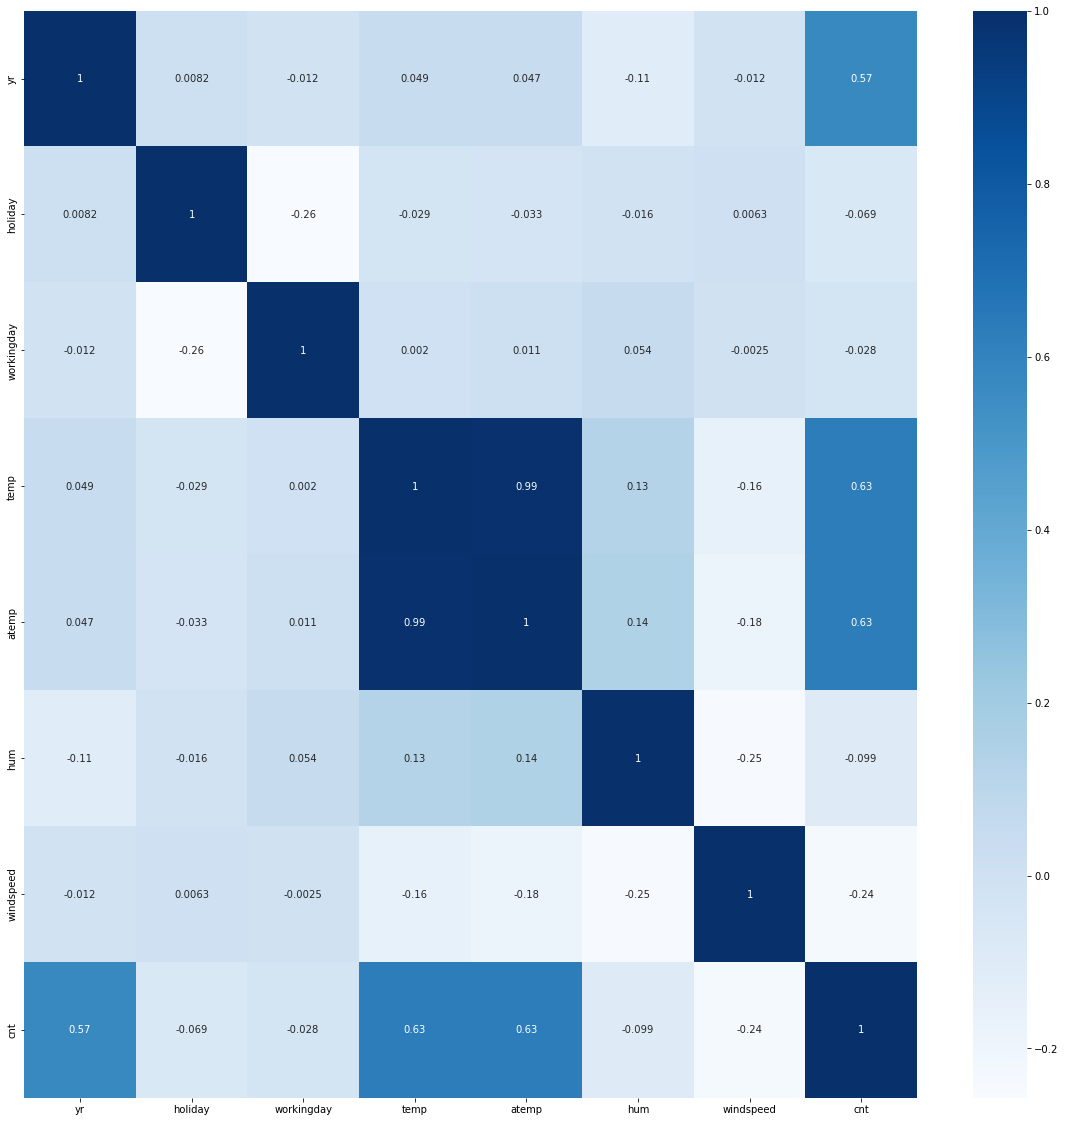

In [23]:
# correaltion between Numerical variables using heat map
plt.figure(figsize=(20, 20))
sns.heatmap(bike_demand_data.corr(), annot=True, cmap='Blues')
plt.show()

 <div class="alert alert-block alert-info">
<font size="3"> Creating dummy Variables. </font>
</div>

In [24]:

dum1=pd.get_dummies(bike_demand_data,columns=['season','mnth','weekday'], drop_first = True)
dum2=pd.get_dummies(bike_demand_data['weathersit'])

dum1.head()

,yr,holiday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,season_spring,...,mnth_may,mnth_november,mnth_october,mnth_september,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed
0,0,0,1,moderate_weather,14.110847,18.18125,80.5833,10.749882,985,1,...,0,0,0,0,1,0,0,0,0,0
1,0,0,1,moderate_weather,14.902598,17.68695,69.6087,16.652113,801,1,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,Good_weather,8.050924,9.47025,43.7273,16.636703,1349,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,1,Good_weather,8.200000,10.60610,59.0435,10.739832,1562,1,...,0,0,0,0,0,0,0,1,0,0
4,0,0,1,Good_weather,9.305237,11.46350,43.6957,12.522300,1600,1,...,0,0,0,0,0,0,0,0,0,0


In [25]:
dum2.head()

,Good_weather,bad_weather,moderate_weather
0,0,0,1
1,0,0,1
2,1,0,0
3,1,0,0
4,1,0,0


In [26]:
bike_demand_data=pd.concat([dum1,dum2],axis=1)

In [27]:
bike_demand_data.head()

,yr,holiday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,season_spring,...,mnth_september,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,Good_weather,bad_weather,moderate_weather
0,0,0,1,moderate_weather,14.110847,18.18125,80.5833,10.749882,985,1,...,0,1,0,0,0,0,0,0,0,1
1,0,0,1,moderate_weather,14.902598,17.68695,69.6087,16.652113,801,1,...,0,0,0,0,0,1,0,0,0,1
2,0,0,1,Good_weather,8.050924,9.47025,43.7273,16.636703,1349,1,...,0,0,0,0,0,0,1,1,0,0
3,0,0,1,Good_weather,8.200000,10.60610,59.0435,10.739832,1562,1,...,0,0,0,0,1,0,0,1,0,0
4,0,0,1,Good_weather,9.305237,11.46350,43.6957,12.522300,1600,1,...,0,0,0,0,0,0,0,1,0,0


 <div class="alert alert-block alert-info">
<font size="3"> Dropping weathersit column for linear regression modeling as it containg cateogarical value. </font>
</div>

In [28]:
bike_demand_data=bike_demand_data.drop('weathersit',axis=1)

 <div class="alert alert-block alert-info">
<font size="3"> Making copy of original dataframe. </font>
</div>

In [29]:
bike_df=bike_demand_data.copy()

In [30]:
bike_df.shape

(730, 31)

In [31]:
bike_df.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_spring,season_summer,...,mnth_september,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,Good_weather,bad_weather,moderate_weather
0,0,0,1,14.110847,18.18125,80.5833,10.749882,985,1,0,...,0,1,0,0,0,0,0,0,0,1
1,0,0,1,14.902598,17.68695,69.6087,16.652113,801,1,0,...,0,0,0,0,0,1,0,0,0,1
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,1,0,...,0,0,0,0,0,0,1,1,0,0
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,1,0,...,0,0,0,0,1,0,0,1,0,0
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,1,0,...,0,0,0,0,0,0,0,1,0,0


In [32]:
bike_df.columns

Index(['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed',
       'cnt', 'season_spring', 'season_summer', 'season_winter', 'mnth_august',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
       'mnth_june', 'mnth_march', 'mnth_may', 'mnth_november', 'mnth_october',
       'mnth_september', 'weekday_Mon', 'weekday_Sat', 'weekday_Sun',
       'weekday_Thu', 'weekday_Tue', 'weekday_Wed', 'Good_weather',
       'bad_weather', 'moderate_weather'],
      dtype='object')

In [36]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yr                730 non-null    int64  
 1   holiday           730 non-null    int64  
 2   workingday        730 non-null    int64  
 3   temp              730 non-null    float64
 4   atemp             730 non-null    float64
 5   hum               730 non-null    float64
 6   windspeed         730 non-null    float64
 7   cnt               730 non-null    int64  
 8   season_spring     730 non-null    uint8  
 9   season_summer     730 non-null    uint8  
 10  season_winter     730 non-null    uint8  
 11  mnth_august       730 non-null    uint8  
 12  mnth_december     730 non-null    uint8  
 13  mnth_february     730 non-null    uint8  
 14  mnth_january      730 non-null    uint8  
 15  mnth_july         730 non-null    uint8  
 16  mnth_june         730 non-null    uint8  
 1

In [37]:
# y to contain only target variable
y = bike_df.pop('cnt')

# X is all remaining variable also our independent variables
X = bike_df



In [39]:
#70:30 RATIO
from sklearn.model_selection import train_test_split
np.random.seed(0)
X_train, X_test, y_train, y_test =train_test_split(X,y,train_size=0.7,test_size=0.3,random_state=42)

In [40]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 510 entries, 683 to 435
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yr                510 non-null    int64  
 1   holiday           510 non-null    int64  
 2   workingday        510 non-null    int64  
 3   temp              510 non-null    float64
 4   atemp             510 non-null    float64
 5   hum               510 non-null    float64
 6   windspeed         510 non-null    float64
 7   season_spring     510 non-null    uint8  
 8   season_summer     510 non-null    uint8  
 9   season_winter     510 non-null    uint8  
 10  mnth_august       510 non-null    uint8  
 11  mnth_december     510 non-null    uint8  
 12  mnth_february     510 non-null    uint8  
 13  mnth_january      510 non-null    uint8  
 14  mnth_july         510 non-null    uint8  
 15  mnth_june         510 non-null    uint8  
 16  mnth_march        510 non-null    uint8  


In [41]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 219 entries, 468 to 314
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yr                219 non-null    int64  
 1   holiday           219 non-null    int64  
 2   workingday        219 non-null    int64  
 3   temp              219 non-null    float64
 4   atemp             219 non-null    float64
 5   hum               219 non-null    float64
 6   windspeed         219 non-null    float64
 7   season_spring     219 non-null    uint8  
 8   season_summer     219 non-null    uint8  
 9   season_winter     219 non-null    uint8  
 10  mnth_august       219 non-null    uint8  
 11  mnth_december     219 non-null    uint8  
 12  mnth_february     219 non-null    uint8  
 13  mnth_january      219 non-null    uint8  
 14  mnth_july         219 non-null    uint8  
 15  mnth_june         219 non-null    uint8  
 16  mnth_march        219 non-null    uint8  


In [44]:
# Checking shape and size for test and train

print(X_train.shape)
print(X_test.shape)

(510, 30)
(219, 30)


In [45]:
X_train.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,season_spring,season_summer,season_winter,...,mnth_september,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,Good_weather,bad_weather,moderate_weather
683,1,0,1,13.188347,16.22460,62.0417,10.250129,0,0,1,...,0,0,0,0,0,0,0,0,0,1
645,1,1,0,15.716653,19.38040,70.9583,12.708493,0,0,1,...,0,0,0,0,0,1,0,0,0,1
163,0,0,1,26.035000,30.08270,49.4583,20.458450,0,1,0,...,0,0,0,0,0,0,1,1,0,0
360,0,0,1,13.325000,16.38165,76.2500,12.626150,1,0,0,...,0,0,0,0,1,0,0,0,0,1
640,1,0,1,26.957500,29.95665,79.3750,4.458569,0,0,1,...,0,0,0,0,1,0,0,0,0,1


In [46]:
X_test.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,season_spring,season_summer,season_winter,...,mnth_september,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,Good_weather,bad_weather,moderate_weather
468,1,0,0,20.295000,24.39980,50.2917,12.791439,0,1,0,...,0,0,0,1,0,0,0,1,0,0
148,0,0,1,27.367500,30.77750,81.8750,14.333846,0,1,0,...,0,0,0,0,0,1,0,1,0,0
302,0,0,1,13.085847,16.06645,62.3750,11.833339,0,0,1,...,0,0,0,0,0,1,0,1,0,0
355,0,0,0,17.356653,21.30605,75.7500,3.167425,1,0,0,...,0,0,1,0,0,0,0,0,0,1
515,1,0,1,27.880000,31.56645,49.2917,13.083693,0,1,0,...,0,0,0,0,0,0,0,1,0,0


 <div class="alert alert-block alert-info">
<font size="3"> Importing necessary library. </font>
</div>

In [47]:
# Importing requried libraries

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
# from sklearn.model_selection import train_test_split already imported above
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

 <div class="alert alert-block alert-info">
<font size="3"> Performing EDA on taining data. </font>
</div>

 <div class="alert alert-block alert-info">
<font size="3"> On numerical variable. </font>
</div>

<Figure size 720x720 with 0 Axes>

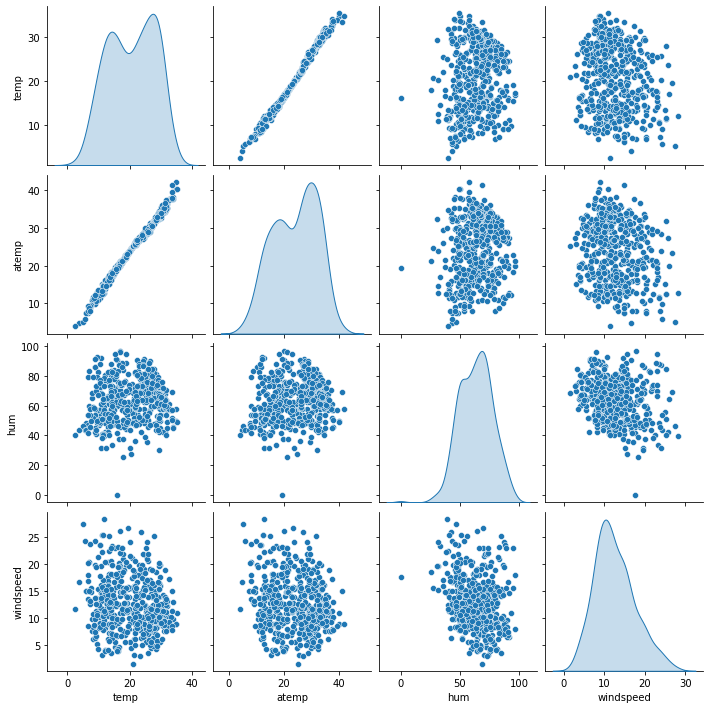

In [49]:
plt.figure(figsize=(10,10))
bike_num=X_train[[ 'temp', 'atemp', 'hum', 'windspeed']]
sns.pairplot(bike_num, diag_kind='kde')
plt.show()

 <div class="alert alert-block alert-info">
<font size="3"> correlation matrix. </font>
</div>

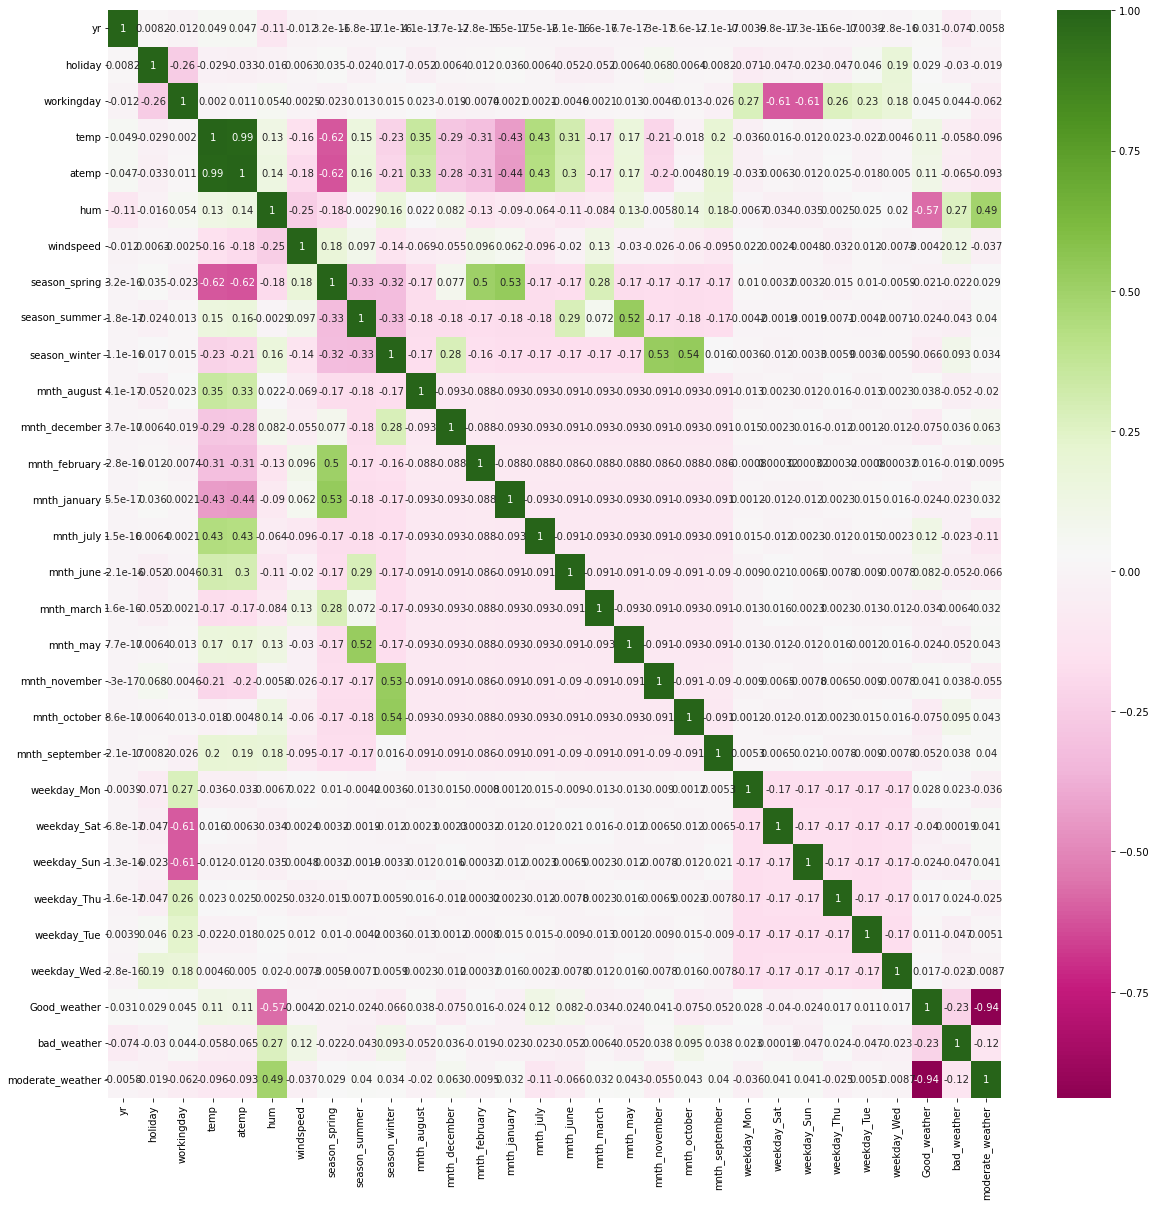

In [50]:
plt.figure(figsize = (20,20))
sns.heatmap(bike_df.corr(), annot = True, cmap="PiYG")
plt.show()

 <div class="alert alert-block alert-info">
<font size="5"> Scaling using MinMax. </font>
</div>

In [51]:
import warnings
warnings.ignore=True

In [52]:
from sklearn.preprocessing import MinMaxScaler

In [53]:
scaler = MinMaxScaler()

In [54]:
vars_num = ['temp', 'atemp', 'hum', 'windspeed']
X_train[vars_num] = scaler.fit_transform(X_train[vars_num])

C:\Users\Akarsh\anaconda3\lib\site-packages\pandas\core\frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


In [55]:
X_train.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,season_spring,season_summer,season_winter,...,mnth_september,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,Good_weather,bad_weather,moderate_weather
683,1,0,1,0.327133,0.322150,0.639330,0.327101,0,0,1,...,0,0,0,0,0,0,0,0,0,1
645,1,1,0,0.403972,0.404998,0.731215,0.419004,0,0,1,...,0,0,0,0,0,1,0,0,0,1
163,0,0,1,0.717562,0.685963,0.509660,0.708724,0,1,0,...,0,0,0,0,0,0,1,1,0,0
360,0,0,1,0.331287,0.326273,0.785745,0.415925,1,0,0,...,0,0,0,0,1,0,0,0,0,1
640,1,0,1,0.745598,0.682653,0.817947,0.110593,0,0,1,...,0,0,0,0,1,0,0,0,0,1


 <div class="alert alert-block alert-info">
<font size="5"> Building Linear Regression model using RFE. </font>
</div>

In [56]:
X_train.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,season_spring,season_summer,season_winter,...,mnth_september,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,Good_weather,bad_weather,moderate_weather
683,1,0,1,0.327133,0.322150,0.639330,0.327101,0,0,1,...,0,0,0,0,0,0,0,0,0,1
645,1,1,0,0.403972,0.404998,0.731215,0.419004,0,0,1,...,0,0,0,0,0,1,0,0,0,1
163,0,0,1,0.717562,0.685963,0.509660,0.708724,0,1,0,...,0,0,0,0,0,0,1,1,0,0
360,0,0,1,0.331287,0.326273,0.785745,0.415925,1,0,0,...,0,0,0,0,1,0,0,0,0,1
640,1,0,1,0.745598,0.682653,0.817947,0.110593,0,0,1,...,0,0,0,0,1,0,0,0,0,1


In [57]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

 <div class="alert alert-block alert-info">
<font size="3"> Running RFE. </font>
</div>

In [58]:
rfe=RFE(lr,22)
rfe=rfe.fit(X_train,y_train)

C:\Users\Akarsh\anaconda3\lib\site-packages\sklearn\utils\validation.py:70: FutureWarning: Pass n_features_to_select=22 as keyword args. From version 1.0 (renaming of 0.25) passing these as positional arguments will result in an error
  warnings.warn(f"Pass {args_msg} as keyword args. From version "


In [59]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('yr', True, 1),
 ('holiday', True, 1),
 ('workingday', False, 4),
 ('temp', True, 1),
 ('atemp', True, 1),
 ('hum', True, 1),
 ('windspeed', True, 1),
 ('season_spring', True, 1),
 ('season_summer', True, 1),
 ('season_winter', True, 1),
 ('mnth_august', False, 6),
 ('mnth_december', True, 1),
 ('mnth_february', False, 2),
 ('mnth_january', False, 8),
 ('mnth_july', True, 1),
 ('mnth_june', False, 3),
 ('mnth_march', True, 1),
 ('mnth_may', True, 1),
 ('mnth_november', True, 1),
 ('mnth_october', True, 1),
 ('mnth_september', True, 1),
 ('weekday_Mon', True, 1),
 ('weekday_Sat', False, 5),
 ('weekday_Sun', False, 7),
 ('weekday_Thu', False, 9),
 ('weekday_Tue', True, 1),
 ('weekday_Wed', True, 1),
 ('Good_weather', True, 1),
 ('bad_weather', True, 1),
 ('moderate_weather', True, 1)]

In [60]:
X_train.columns[~rfe.support_]

Index(['workingday', 'mnth_august', 'mnth_february', 'mnth_january',
       'mnth_june', 'weekday_Sat', 'weekday_Sun', 'weekday_Thu'],
      dtype='object')

 <div class="alert alert-block alert-info">
<font size="3"> Building linear model using STATS model api </font>
</div>

 <div class="alert alert-block alert-info">
<font size="5">Model -1 </font>
</div>

In [74]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [75]:
#Function to build a model using statsmodel api - Takes the columns to be selected for model as a parameter

def build_model(cols):
    X_train_sm = sm.add_constant(X_train[cols])
    lm = sm.OLS(y_train, X_train_sm).fit()
    print(lm.summary())
    return lm

In [76]:
#Function to calculate VIFs and print them -Takes the columns for which VIF to be calcualted as a parameter

def get_vif(cols):
    df1 = X_train[cols]
    vif = pd.DataFrame()
    vif['Features'] = df1.columns
    vif['VIF'] = [variance_inflation_factor(df1.values, i) for i in range(df1.shape[1])]
    vif['VIF'] = round(vif['VIF'],2)
    print(vif.sort_values(by='VIF',ascending=False))

# not taking atemp as it has high correlation with temp

In [78]:
cols = ['yr', 'holiday', 'workingday', 'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
       'mnth_june', 'mnth_may', 'mnth_november', 'mnth_september',
       'weekday_Mon', 'weekday_Sat', 'weekday_Sun', 'weekday_Tue',
       'weekday_Wed', 'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     117.6
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          1.17e-175
Time:                        22:36:29   Log-Likelihood:                -4124.0
No. Observations:                 510   AIC:                             8292.
Df Residuals:                     488   BIC:                             8385.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1314.7647    676.138  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [77]:
rfe_var=X_train.columns[rfe.support_]
rfe_var

Index(['yr', 'holiday', 'temp', 'atemp', 'hum', 'windspeed', 'season_spring',
       'season_summer', 'season_winter', 'mnth_december', 'mnth_july',
       'mnth_march', 'mnth_may', 'mnth_november', 'mnth_october',
       'mnth_september', 'weekday_Mon', 'weekday_Tue', 'weekday_Wed',
       'Good_weather', 'bad_weather', 'moderate_weather'],
      dtype='object')

 <div class="alert alert-block alert-info">
<font size="5">Checking correlation of features selected by RFE with target column.</font>
</div>

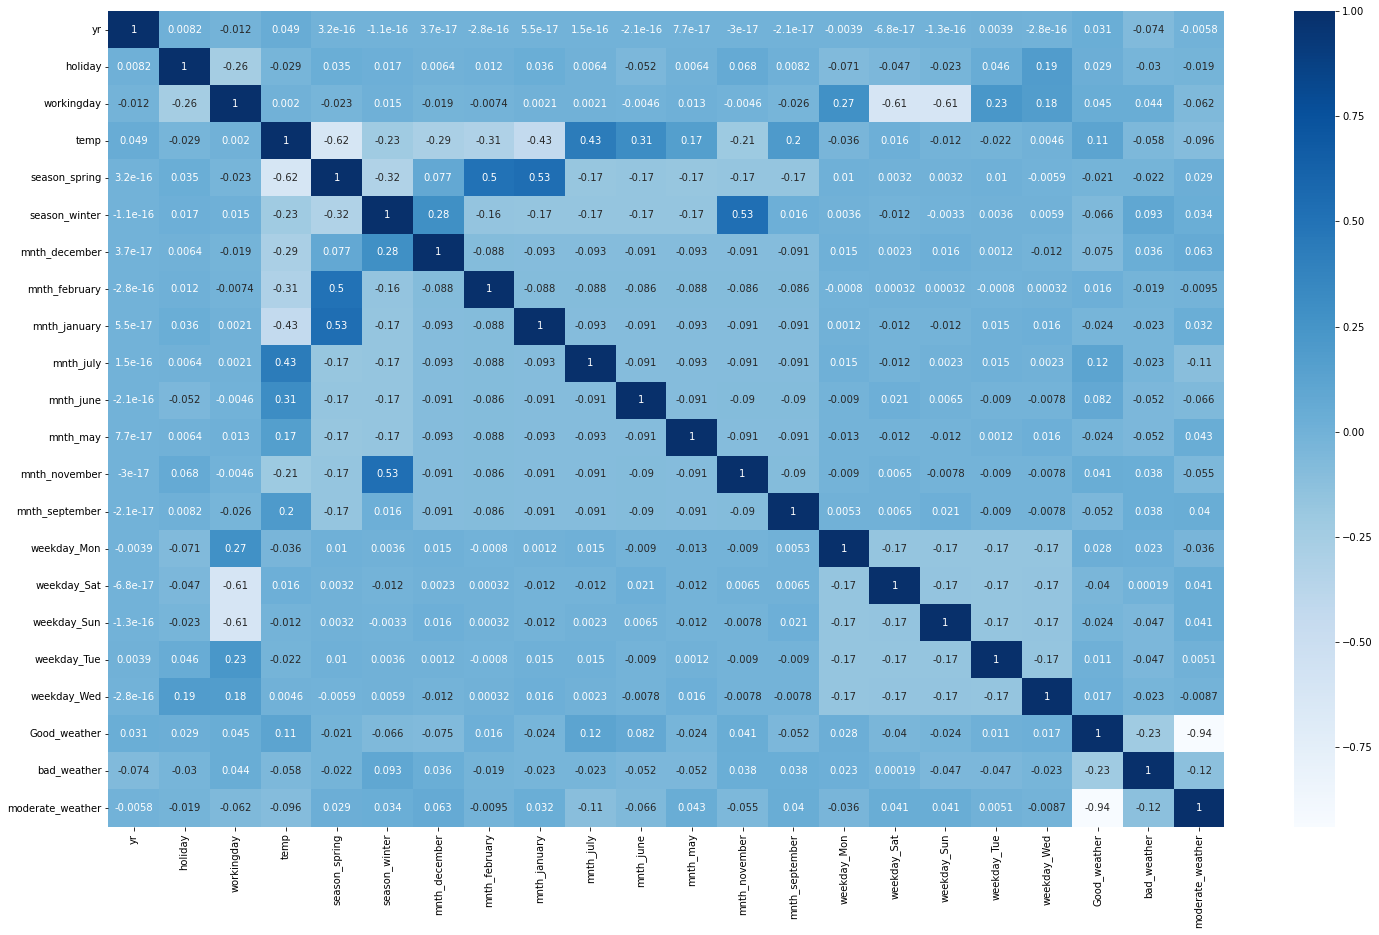

In [79]:
# Also to check impact of different features on target.

plt.figure(figsize = (25,15))
sns.heatmap(bike_df[['yr', 'holiday', 'workingday', 'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
       'mnth_june', 'mnth_may', 'mnth_november', 'mnth_september',
       'weekday_Mon', 'weekday_Sat', 'weekday_Sun', 'weekday_Tue',
       'weekday_Wed', 'Good_weather', 'bad_weather', 'moderate_weather']].corr(), cmap='Blues', annot=True)
plt.show()

 <div class="alert alert-block alert-info">
<font size="5">Now we will drop variable one by one and see the best model fit.</font>
</div>

In [80]:
# dropping 'workingday', as it has high p value 

In [81]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
       'mnth_june', 'mnth_may', 'mnth_november', 'mnth_september',
       'weekday_Mon', 'weekday_Sat', 'weekday_Sun', 'weekday_Tue',
       'weekday_Wed', 'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     123.6
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          1.13e-176
Time:                        22:36:42   Log-Likelihood:                -4124.1
No. Observations:                 510   AIC:                             8290.
Df Residuals:                     489   BIC:                             8379.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1040.4953    171.850  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [82]:
# dropping weekday_Sat as it has high p value  

In [83]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
       'mnth_june', 'mnth_may', 'mnth_november', 'mnth_september',
       'weekday_Mon',  'weekday_Sun', 'weekday_Tue',
       'weekday_Wed', 'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     130.4
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          1.01e-177
Time:                        22:36:46   Log-Likelihood:                -4124.1
No. Observations:                 510   AIC:                             8288.
Df Residuals:                     490   BIC:                             8373.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1048.2695    169.409  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [84]:
# dropping 'mnth_june',as it has high p-value

In [85]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
        'mnth_may', 'mnth_november', 'mnth_september',
       'weekday_Mon',  'weekday_Sun', 'weekday_Tue',
       'weekday_Wed', 'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     137.6
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          1.26e-178
Time:                        22:36:47   Log-Likelihood:                -4124.6
No. Observations:                 510   AIC:                             8287.
Df Residuals:                     491   BIC:                             8368.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1028.7372    167.942  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [86]:
# dropping mnth_may as it has high p-value

In [87]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
         'mnth_november', 'mnth_september',
       'weekday_Mon',  'weekday_Sun', 'weekday_Tue',
       'weekday_Wed', 'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     145.2
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          3.49e-179
Time:                        22:36:48   Log-Likelihood:                -4125.8
No. Observations:                 510   AIC:                             8288.
Df Residuals:                     492   BIC:                             8364.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1067.7345    166.345  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [88]:
# dropping weekday_Sun    as it has high p-value  low vif        

In [89]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
         'mnth_november', 'mnth_september','weekday_Mon',  'weekday_Tue',
       'weekday_Wed', 'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     154.5
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          2.94e-180
Time:                        22:36:49   Log-Likelihood:                -4125.9
No. Observations:                 510   AIC:                             8286.
Df Residuals:                     493   BIC:                             8358.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1075.4257    164.766  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [90]:
# dropping weekday_Tue as it has high p-value

In [91]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
         'mnth_november', 'mnth_september',
       'weekday_Mon', 'weekday_Wed', 'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     162.2
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          8.41e-180
Time:                        22:36:50   Log-Likelihood:                -4129.7
No. Observations:                 510   AIC:                             8291.
Df Residuals:                     494   BIC:                             8359.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1011.9147    164.125  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [92]:
#dropping weekday_Wed as it has little high p-value, and improving f statistic considerably

In [93]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
         'mnth_november', 'mnth_september','weekday_Mon',  
        'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     172.7
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          3.62e-180
Time:                        22:36:52   Log-Likelihood:                -4131.5
No. Observations:                 510   AIC:                             8293.
Df Residuals:                     495   BIC:                             8356.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              994.5285    164.284  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [94]:
# drop weekday_Mon  as it has little high p-value, and improving f statistic considerably  

In [95]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december', 'mnth_february', 'mnth_january', 'mnth_july',
         'mnth_november', 'mnth_september',
         'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     183.2
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          8.20e-180
Time:                        22:36:54   Log-Likelihood:                -4135.0
No. Observations:                 510   AIC:                             8298.
Df Residuals:                     496   BIC:                             8357.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              929.1414    163.380  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [96]:
# drop mnth_february     as it has little high p-value, and improving f statistic considerably

In [97]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december',  'mnth_january', 'mnth_july',
         'mnth_november', 'mnth_september',
         'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     197.7
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          2.05e-180
Time:                        22:36:55   Log-Likelihood:                -4136.4
No. Observations:                 510   AIC:                             8299.
Df Residuals:                     497   BIC:                             8354.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              883.0816    161.095  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [98]:
# drop mnth_january     as it has little high p-value, and improving f statistic considerably

In [99]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december',   'mnth_july',
         'mnth_november', 'mnth_september',
         'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     214.5
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          5.99e-181
Time:                        22:36:56   Log-Likelihood:                -4137.9
No. Observations:                 510   AIC:                             8300.
Df Residuals:                     498   BIC:                             8351.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              820.6651    157.289  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [100]:
# drop VIF>5 good_weather

In [101]:
cols = ['yr', 'holiday',  'temp', 'season_spring', 'season_winter',
       'mnth_december',   'mnth_july',
         'mnth_november', 'mnth_september',
         'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     214.5
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          5.99e-181
Time:                        22:37:01   Log-Likelihood:                -4137.9
No. Observations:                 510   AIC:                             8300.
Df Residuals:                     498   BIC:                             8351.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              820.6651    157.289  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [102]:
# dropping holiday. significantly increased f statistic.

In [103]:
cols = ['yr',   'temp', 'season_spring', 'season_winter',
       'mnth_december',   'mnth_july',
         'mnth_november', 'mnth_september',
         
        'Good_weather', 'bad_weather', 'moderate_weather']

build_model(cols)
get_vif(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     232.0
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          1.83e-180
Time:                        22:37:06   Log-Likelihood:                -4141.9
No. Observations:                 510   AIC:                             8306.
Df Residuals:                     499   BIC:                             8352.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              818.8640    158.359  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


 <div class="alert alert-block alert-info">
<font size="5">Watching correlation  among leftout variables used for prediction.</font>
</div>

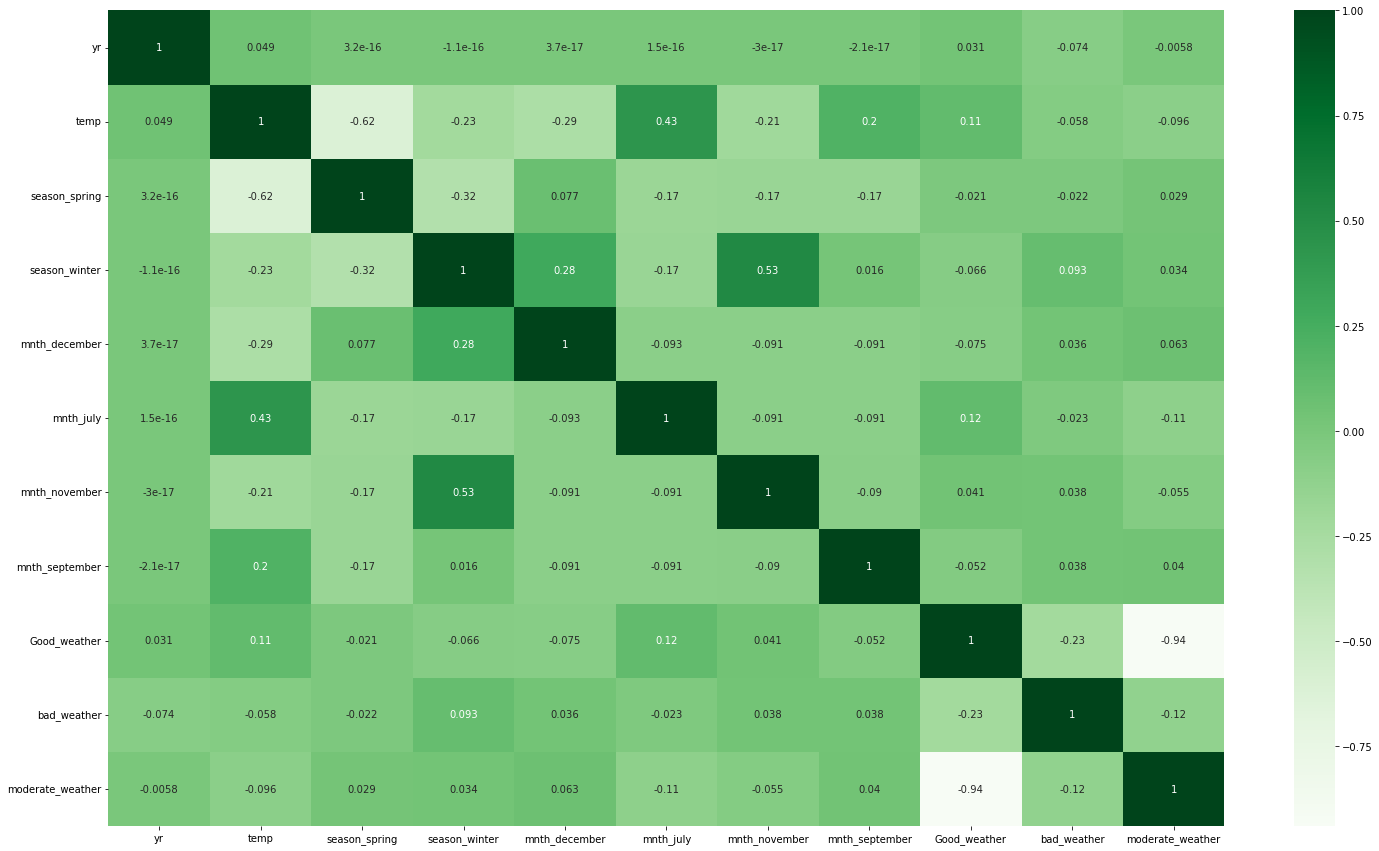

In [104]:
# Also to check impact of different features on target.

plt.figure(figsize = (25,15))
sns.heatmap(bike_df[['yr',   'temp', 'season_spring', 'season_winter',
       'mnth_december',   'mnth_july',
         'mnth_november', 'mnth_september',
        'Good_weather', 'bad_weather', 'moderate_weather']].corr(), cmap='Greens', annot=True)
plt.show()

In [ ]:
# ---------------------------------------------------------------------

#### 
<div class="alert alert-block alert-success">
<font size="3"><b>    
The equation of best fitted surface based on model:</b> cnt= 818.8640 +
(yr          *      2000.5710 )+    
(temp         *     3536.3016 )+   
(season_spring *   -1288.2825 )-   
(season_winter  *    756.4004 )+   
(mnth_december   *  -565.0618 ) -  
(mnth_july        * -446.7110 ) -
(mnth_november    * -710.8673 )  -
(mnth_september   *  399.1121 )+   
(Good_weather     * 1268.4770 )+ 
(bad_weather      *-1043.0345 )   -
(moderate_weather  * 593.4215).</font >
</div>



    


#### 
<div class="alert alert-block alert-success">
<font size="3"><b>Inference:</b>This model looks good, as there seems to be VERY LOW Multicollinearity between the predictors and the p-values for all the predictors seems to be significant. For now, we will consider this as our final model (unless the Test data metrics are not significantly close to this number.</font >
</div>





 <div class="alert alert-block alert-info">
<font size="5">ASSUMPTIONS
Error terms are normally distributed with mean zero (not X, Y)

    Residual Analysis Of Training Data.
    
   </font>
</div>




In [105]:
#Build a model with all columns to select features automatically

def build_model_sk(X,y):
    lr_model = LinearRegression()
    lr_model.fit(X,y)
    return lr_model

In [106]:
#Let us build the finalmodel using sklearn

cols = ['yr',   'temp', 'season_spring', 'season_winter',
       'mnth_december',   'mnth_july',
         'mnth_november', 'mnth_september',
        'Good_weather', 'bad_weather', 'moderate_weather']

#Build a model with above columns
lr = build_model_sk(X_train[cols],y_train)
print(lr.intercept_,lr.coef_)

1091.8186516956926 [ 2000.57100946  3536.30160283 -1288.28253509   756.40035582
  -565.06181191  -446.71098975  -710.86727561   399.11211224
   995.5223044  -1315.98914869   320.46684429]


 <div class="alert alert-block alert-info">
<font size="5">Model Evaluation 
    
   </font>
</div>




In [107]:
y_train_pred = lr.predict(X_train[cols])

In [108]:
#Plot a histogram of the error terms
def plot_res_dist(actual, predic):
    sns.distplot(actual-predic)
    plt.title('Error Terms')
    plt.xlabel('Errors')

C:\Users\Akarsh\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


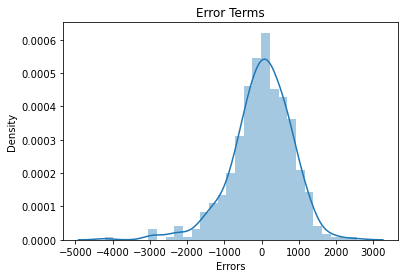

In [109]:
plot_res_dist(y_train, y_train_pred)

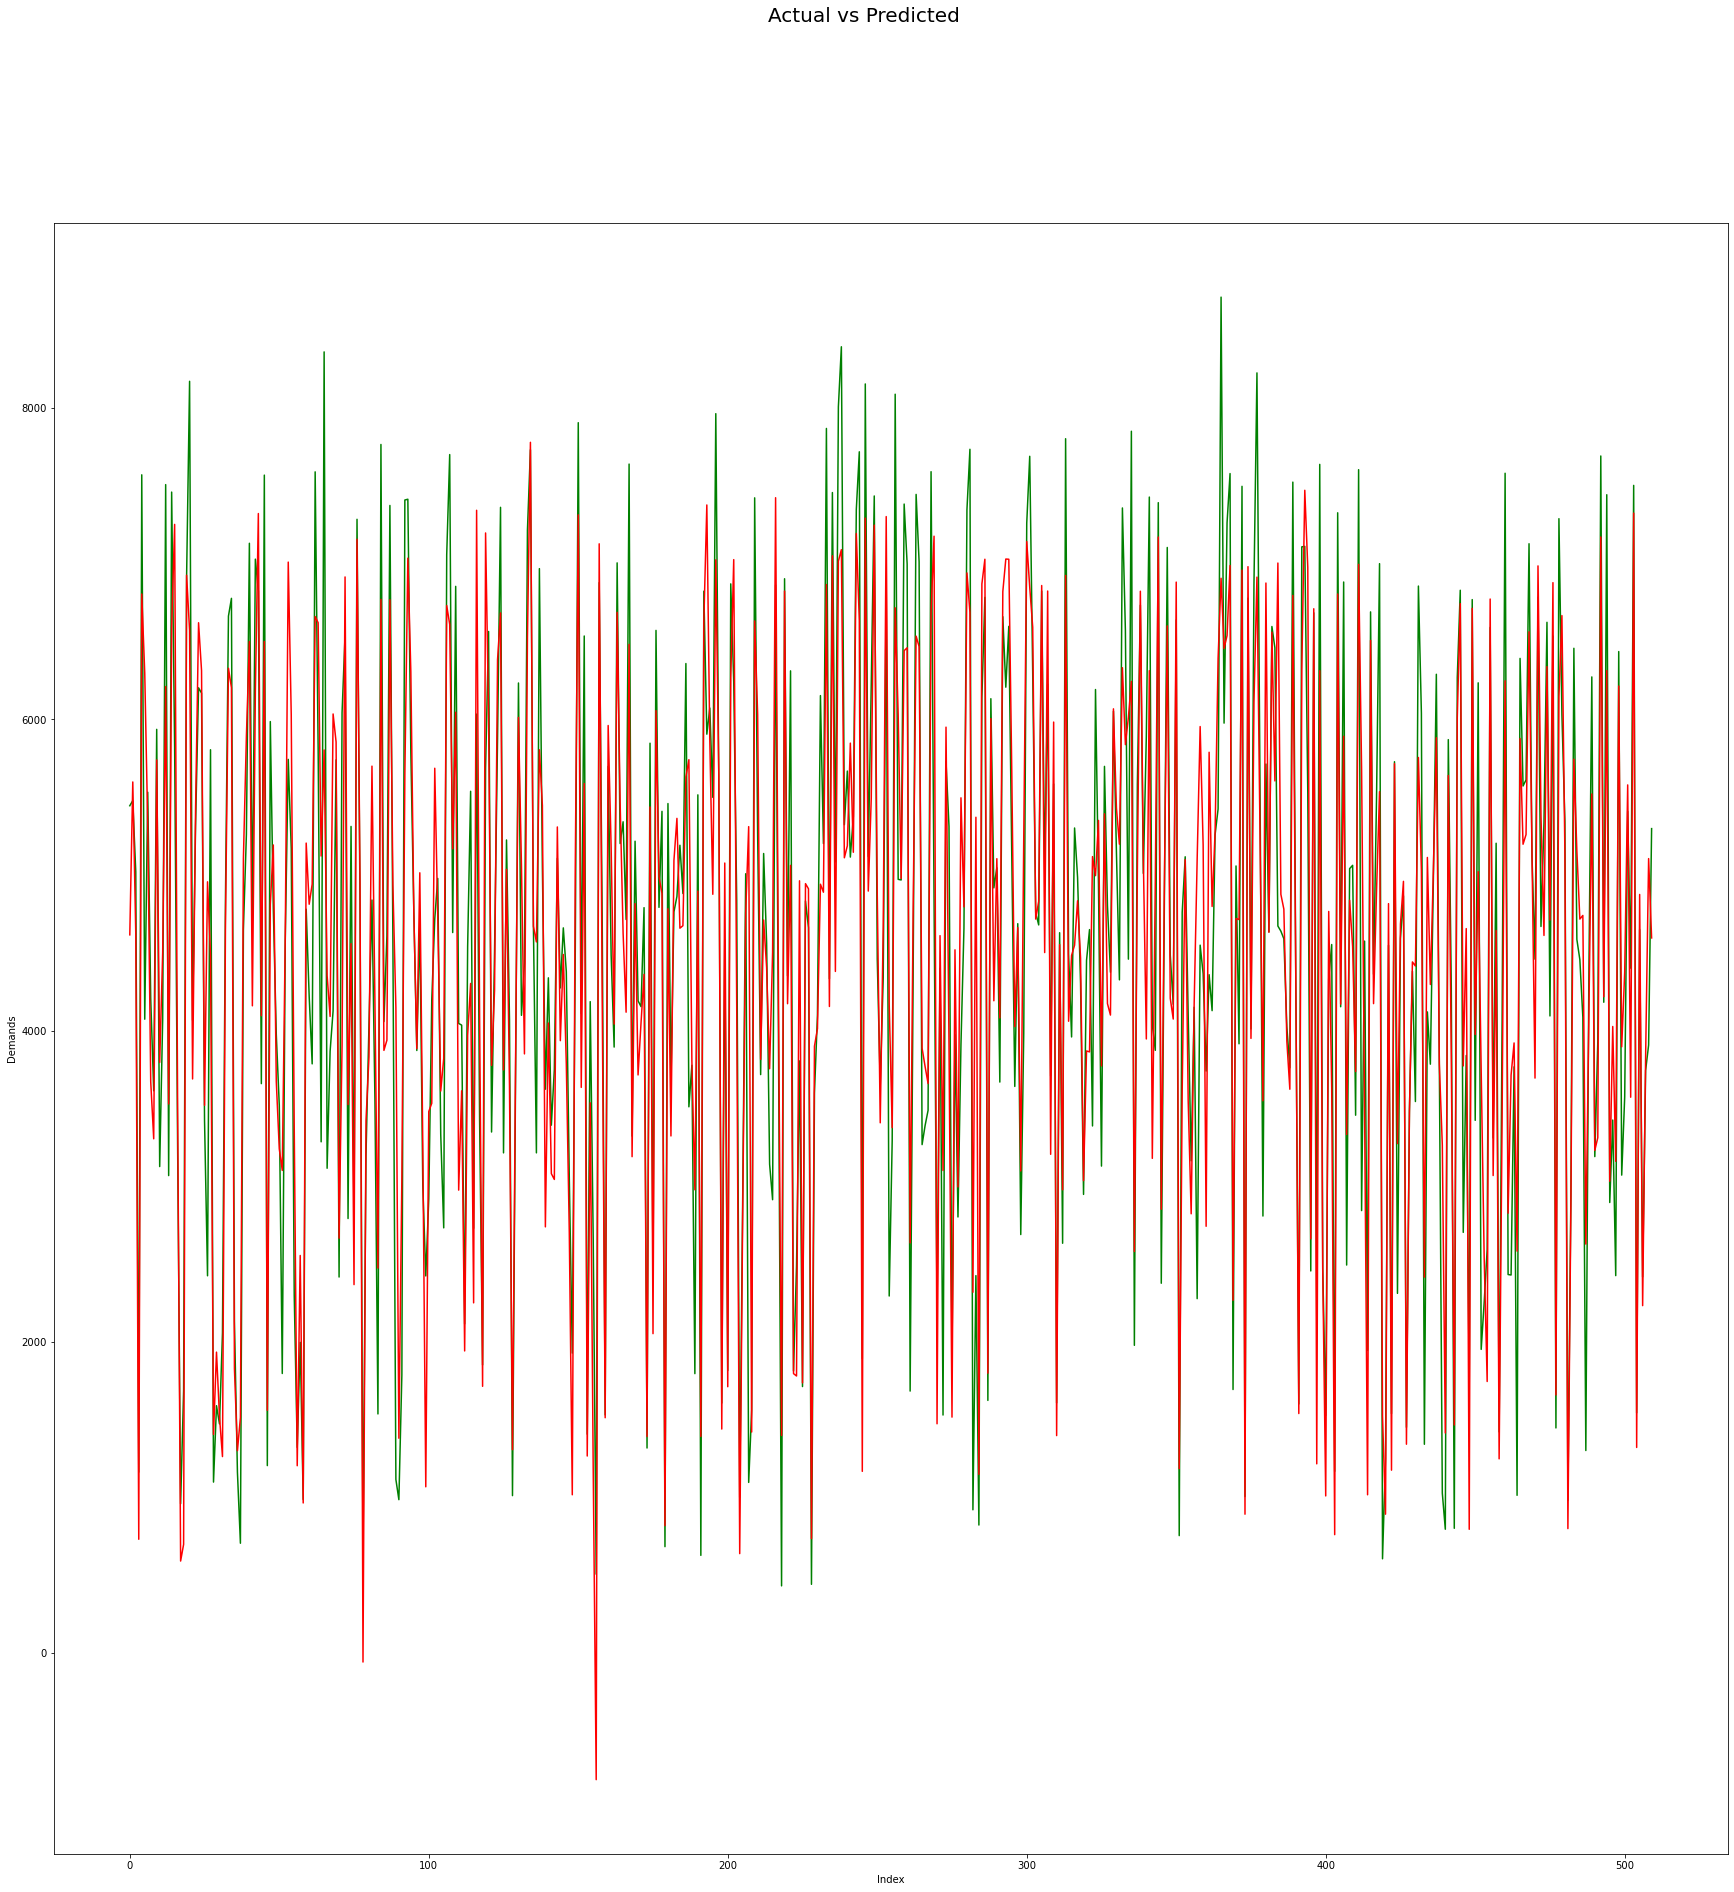

In [110]:
# Actual vs Predicted
plt.figure(figsize=(30,30))
c = [i for i in range(0,len(X_train),1)]
plt.plot(c,y_train, color="green")
plt.plot(c,y_train_pred, color="red")
plt.suptitle('Actual vs Predicted', fontsize = 20)
plt.xlabel('Index')
plt.ylabel('Demands')
plt.show()

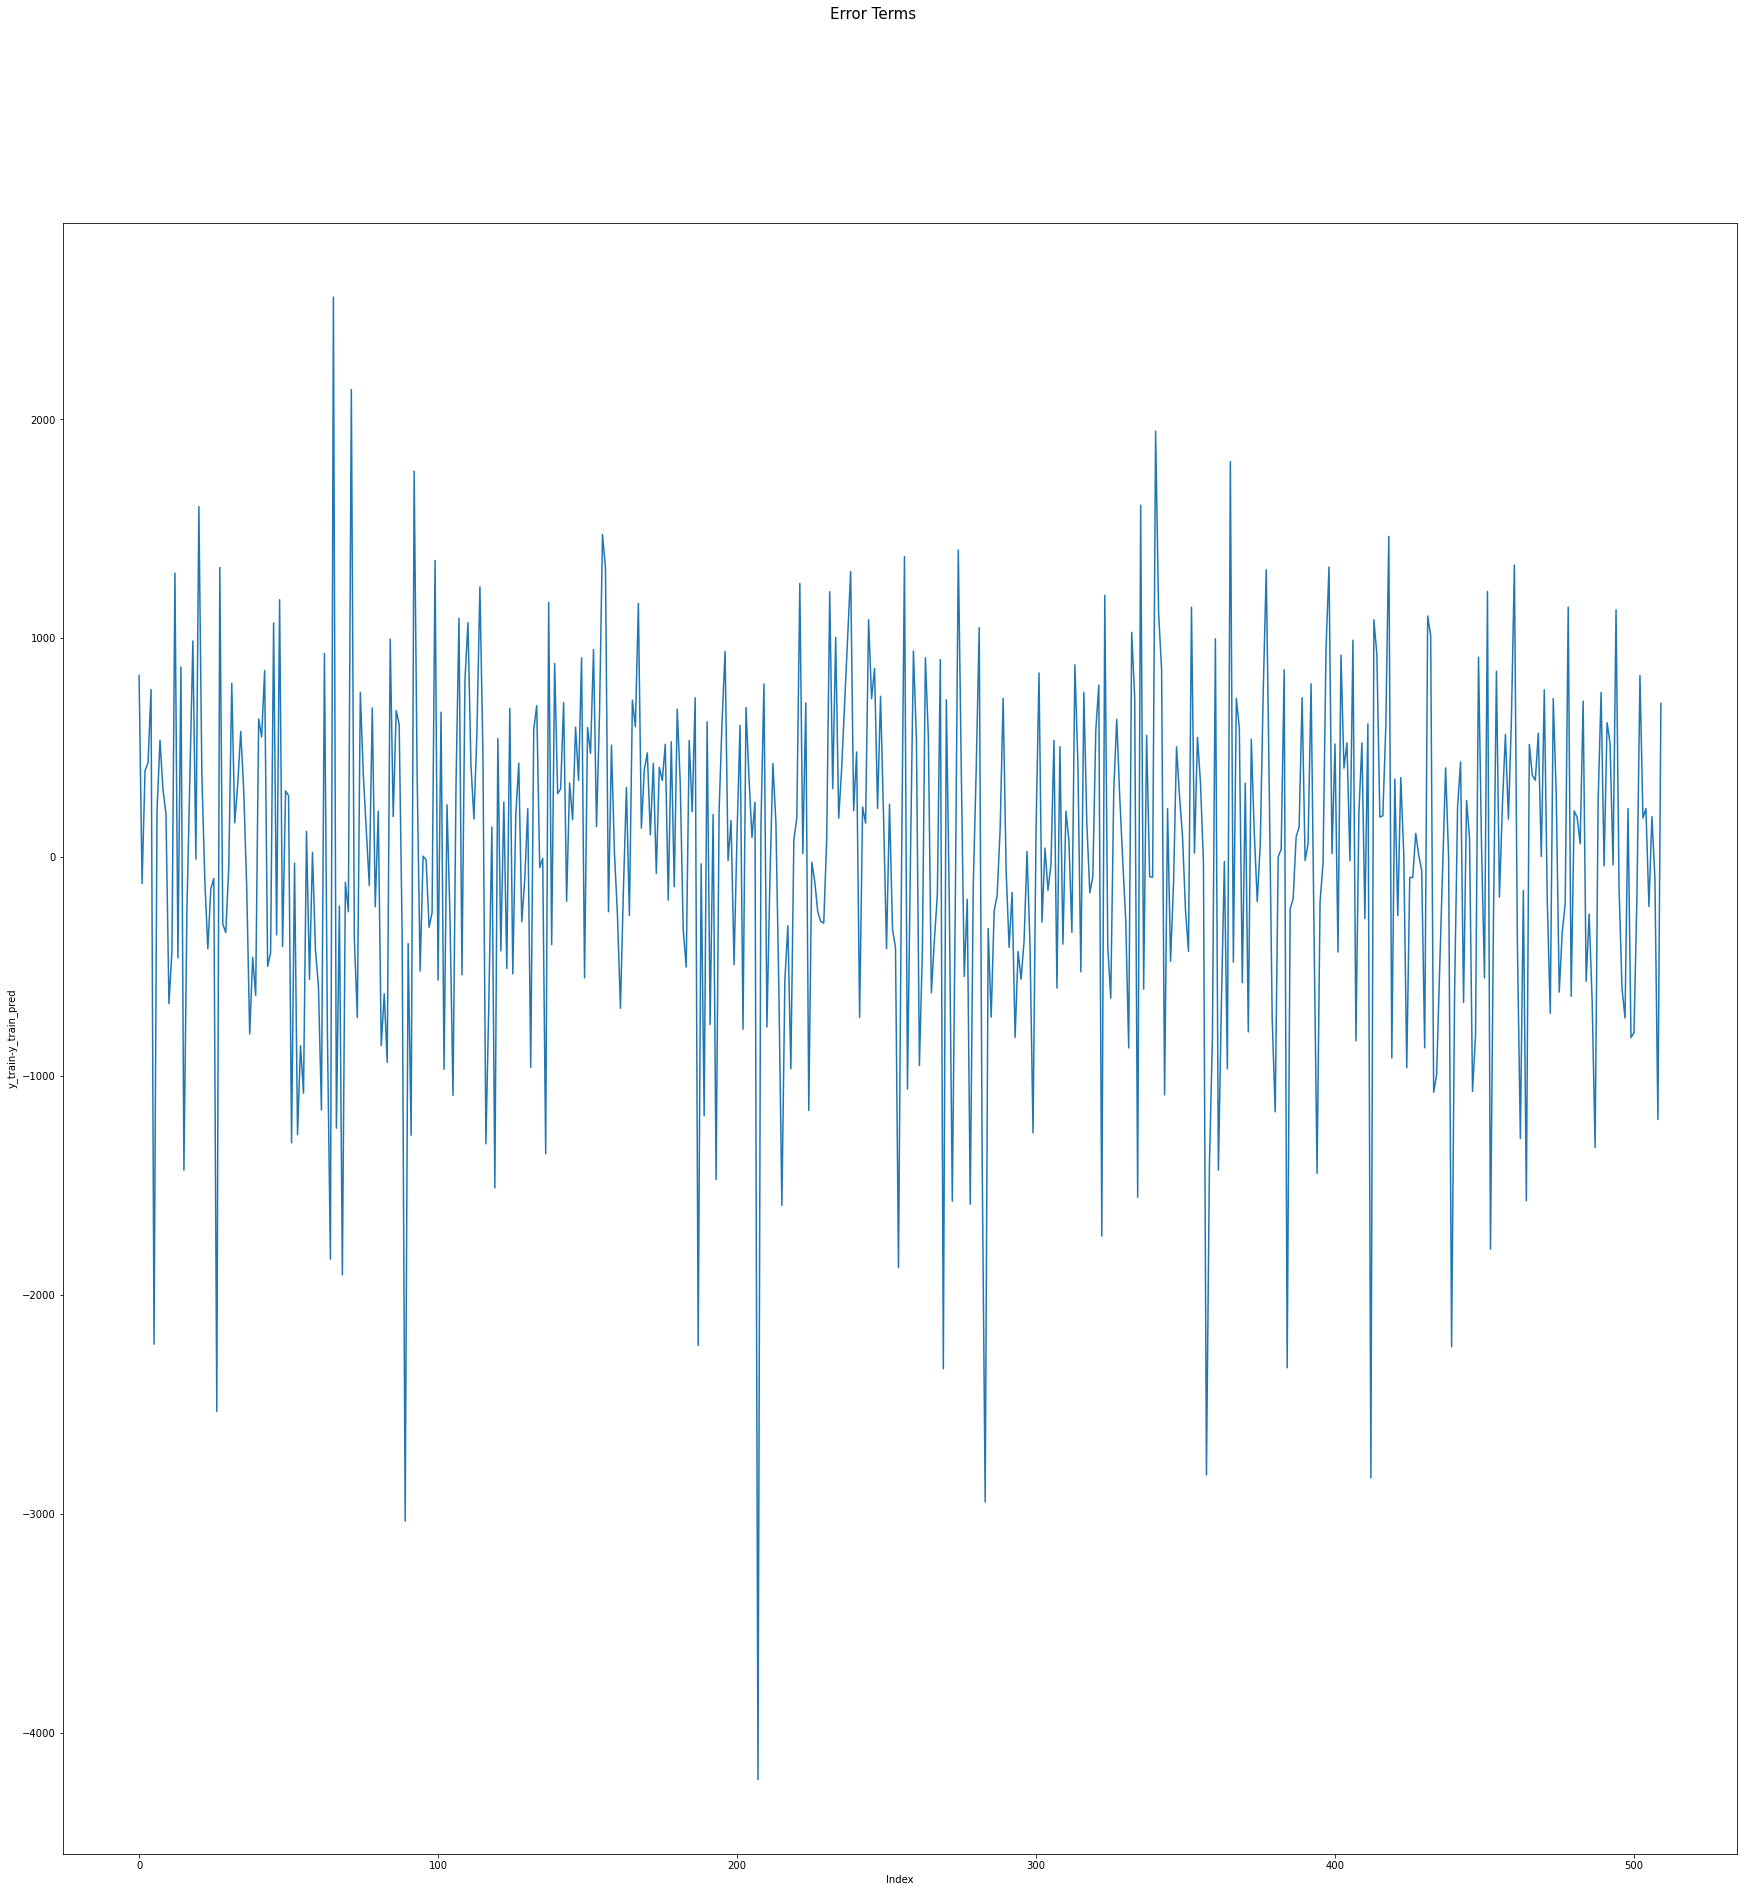

In [128]:
# Error Terms
plt.figure(figsize=(30,30))
c = [i for i in range(0,len(X_train),1)]
plt.plot(c,y_train-y_train_pred)
plt.suptitle('Error Terms', fontsize = 15)
plt.xlabel('Index')
plt.ylabel('y_train-y_train_pred')
plt.show()

 <div class="alert alert-block alert-info">
<font size="3">R2 score for train model 
    
   </font>
</div>




In [129]:
#Print R-squared Value
r2_score(y_train,y_train_pred)

0.8229936983993822

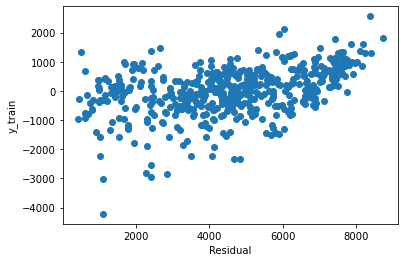

In [113]:
# scatter plot for the check
residual = (y_train - y_train_pred)
plt.scatter(y_train,residual)
plt.ylabel("y_train")
plt.xlabel("Residual")
plt.show()


 <div class="alert alert-block alert-info">
<font size="6">MAKING PREDICTION ON TEST MODEL
    
   </font>
</div>




In [116]:
y_test.head()

468    7460
148    4788
302    3331
355    3068
515    7338
Name: cnt, dtype: int64

In [117]:
#Scale variables in X_test
num_vars =['temp', 'atemp', 'hum', 'windspeed']

#Test data to be transformed only, no fitting
X_test[num_vars] = scaler.transform(X_test[num_vars])

C:\Users\Akarsh\anaconda3\lib\site-packages\pandas\core\frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


In [118]:
#Columns from our final model
cols = ['yr',   'temp', 'season_spring', 'season_winter',
       'mnth_december','mnth_july',
         'mnth_november','mnth_september',
         'Good_weather', 'bad_weather', 'moderate_weather']
#Predict the values for test data
y_test_pred = lr.predict(X_test[cols])

 <div class="alert alert-block alert-info">
<font size="3">R2 score for test model 
    
   </font>
</div>




In [130]:
# Find out the R squared value between test and predicted test data sets.  
r2_score(y_test,y_test_pred)

0.8090937819550367

Text(0, 0.5, 'y_test_pred')

<Figure size 1440x1440 with 0 Axes>

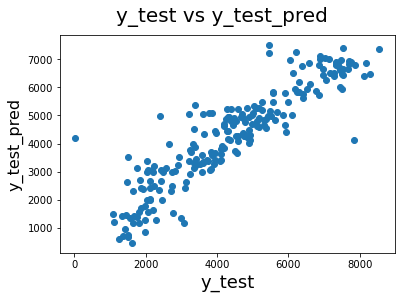

In [131]:
# Plotting y_test and y_test_pred to understand the spread
plt.figure(figsize=(20,20))
fig = plt.figure()
plt.scatter(y_test, y_test_pred)
fig.suptitle('y_test vs y_test_pred', fontsize = 20)         # Plot heading 
plt.xlabel('y_test', fontsize = 18)                          # X-label
plt.ylabel('y_test_pred', fontsize = 16)

 <div class="alert alert-block alert-info">
<font size="3">Plot Actual vs Predicted

    
   </font>
</div>





In [135]:
#Function to plot Actual vs Predicted
#Takes Actual and PRedicted values as input along with the scale and Title to indicate which data
def plot_act_pred(act,pred,scale,dataname):
    c = [i for i in range(1,scale,1)]
    fig = plt.figure(figsize=(14,5))
    plt.plot(c,act, color="blue", linewidth=2.5, linestyle="-")
    plt.plot(c,pred, color="red",  linewidth=2.5, linestyle="-")
    fig.suptitle('Actual and Predicted - '+dataname, fontsize=20)  
    plt.xlabel('Index', fontsize=18)                               
    plt.ylabel('Counts', fontsize=16)                             

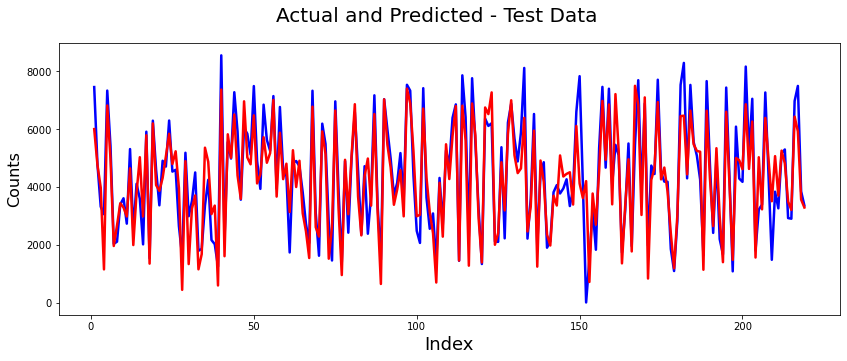

In [134]:
#Plot Actual vs Predicted for Test Data
plot_act_pred(y_test,y_test_pred,len(y_test)+1,'Test Data')

#### 
<div class="alert alert-block alert-success">
    <font size="3"><b>Inference:</b>
          - As we can see predictions for test data is very close to actuals demand is decreasing.
    </font >
</div>


  

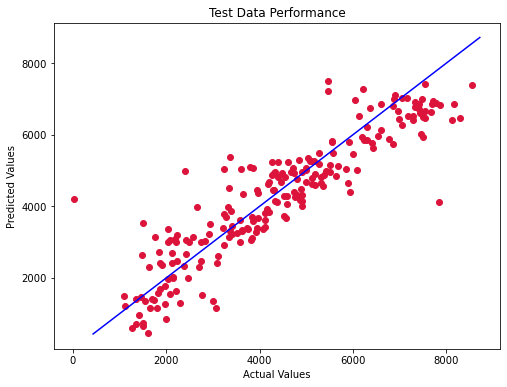

In [136]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, c='crimson')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Test Data Performance")
p1 = max(max(y_test_pred), max(y_train))
p2 = min(min(y_test_pred), min(y_train))
plt.plot([p1, p2], [p1, p2], 'b-')

 <div class="alert alert-block alert-info">
<font size="3">Plotting error terms

    
   </font>
</div>





In [133]:
# Error terms
def plot_err_terms(act,pred):
    c = [i for i in range(1,220,1)]
    fig = plt.figure(figsize=(14,5))
    plt.plot(c,act-pred, color="blue", marker='o', linewidth=2.5, linestyle="")
    fig.suptitle('Error Terms', fontsize=20)              
    plt.xlabel('Index', fontsize=18)                      
    plt.ylabel('Counts - Predicted Counts', fontsize=16)  

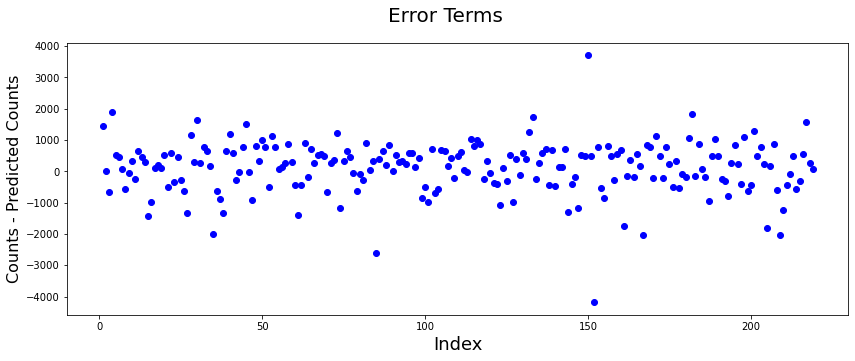

In [127]:
#Plot error terms for test data
plot_err_terms(y_test,y_test_pred)

#### 
<div class="alert alert-block alert-success">
    <font size="3"><b>Inference:</b>
         
   As we can see the error terms are randomly distributed and there is no pattern which means the output is explained  well by model and there are no other parameters that can explain the model better.
    </font >
</div>

In [124]:
#Let us rebuild the final model of manual + rfe approach using statsmodel to interpret it
cols = ['yr', 'holiday', 'temp', 'season_spring', 'season_winter',    'mnth_september'  ,  'bad_weather', 'moderate_weather']

lm = build_model(cols)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     272.8
Date:                Sun, 05 Jun 2022   Prob (F-statistic):          3.84e-177
Time:                        22:38:11   Log-Likelihood:                -4155.5
No. Observations:                 510   AIC:                             8329.
Df Residuals:                     501   BIC:                             8367.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1959.9863    201.409  

C:\Users\Akarsh\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


#### 
<div class="alert alert-block alert-success">
    <font size="3"><b>Analysing the above model, the comapany should focus on the following:</b>
         
    . During the spring, the company should concentrate on growing its business. 
    . During September, the company should concentrate on growing its business. 
    . Previous data indicates that once the situation returns to normal, there will be a surge in the number of users, as compared to 2019.
    . During light snow or rain, there may be fewer bookings; they may use this time to deliver the bikes without affecting business. 
    . Hence when the situation comes back to normal, the company should come up with new offers during spring when the weather is pleasant and also advertise a little for September as this is when business would be at best.
    </font >
</div>


  


#### 
<div class="alert alert-block alert-success">
    <font size="3"><b>
TOP 3 INFLUENCER:</b>
         
    As per our final Model, the top 3 predictor variables that influences the bike booking are:

    . Temperature (temp) - A coefficient value of ‘3576.4598’ indicated that a unit increase in temp variable increases the bike hire numbers by 0.5636 units.
    . season_spring  - A coefficient value of ‘-1217.6811’ indicated that, w.r.t Weathersit1, a unit increase in Weathersit3 variable decreases the bike hire numbers by 1217.6811 units.
    . bad_weather - A coefficient value of ‘-2317.0972 ’ indicated that a unit increase in yr variable increases the bike hire numbers by -2317.0972  units.
    </font >
</div>


  



